In [22]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate, permutation_test_score, cross_val_predict
from sklearn.metrics import (make_scorer, f1_score, precision_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc,
                             classification_report)
from sklearn.inspection import permutation_importance

In [31]:
# -------------------------------------------------------------------
# Load feature matrix
# -------------------------------------------------------------------
df = pd.read_excel(
    "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/feat_table.xlsx", sheet_name='all_feats_new',
    index_col="ID"
)

# -------------------------------------------------------------------
# Features and labels
# -------------------------------------------------------------------
# features above 0.02 mean decrease in impurity only
feature_cols = [
    "Gate mean (A)", "Gate SD (A)",
    "Intermediate %",
    "R_62", "R_163", "R_164", "R_122", "R_83", "R_89", "R_87", "R_159", "R_160", "R_59", "R_116", "R_115", "R_58", 
    "Lb7a5 mean (A)"
]

# feature_cols = [
#     "Gate mean (A)",
#     "Latch mean (A)",
#     "Gate-latch mean (A)",
#     "Closed % (<9.5 A)",   "Open % (>11.5 A)", "Intermediate %",
#     "R_58", "R_59", "R_62",	"R_83",	"R_87",	"R_88",	"R_89",	"R_92",	"R_110", "R_115", "R_116", "R_117", "R_120", "R_122", "R_159",
#     "R_160", "R_163","R_164"
# ]

# all feats
# feature_cols = [
#     "Gate mean (A)",       "Gate SD (A)",
#     "Latch mean (A)",      "Latch SD (A)",
#     "Lb7a5 mean (A)",      "Lb7a5 SD (A)",
#     "Recoil mean (A)",     "Recoil SD (A)",
#     "Gate-latch mean (A)", "Gate-latch SD (A)",
#     "Closed % (<9.5 A)",   "Open % (>11.5 A)", "Intermediate %",
#     "R_58", "R_59", "R_62",	"R_83",	"R_87",	"R_88",	"R_89",	"R_92",	"R_110", "R_115", "R_116", "R_117", "R_120", "R_122", "R_159",
#     "R_160", "R_163","R_164"
# ]

X = df[feature_cols].values
y = df["Label"].values

n_binders    = y.sum()
n_nonbinders = (y == 0).sum()
print(f"Total samples: {len(y)}  |  Binders: {n_binders}  |  Nonbinders: {n_nonbinders}")
print(f"Number of features: {len(feature_cols)}")

Total samples: 127  |  Binders: 37  |  Nonbinders: 90
Number of features: 17


## Binary Classficiation
Testing the Random Forest as a 2-class model: **Binder**, **Nonbinder**.

In [33]:

N_SPLITS = 7
cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

print(f"\n--- Fold composition (n_splits={N_SPLITS}) ---")
for fold, (train_idx, test_idx) in enumerate(cv.split(X, y)):
    n_b_train  = y[train_idx].sum()
    n_b_test   = y[test_idx].sum()
    n_nb_train = (y[train_idx] == 0).sum()
    n_nb_test  = (y[test_idx]  == 0).sum()
    print(f"  Fold {fold+1}: train = {n_b_train} binders / {n_nb_train} nonbinders  |  "
          f"test = {n_b_test} binders / {n_nb_test} nonbinders")


rf = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
)

# -------------------------------------------------------------------
# Stratified cross-validation
# -------------------------------------------------------------------
scoring = {
    "accuracy":          "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc":           "roc_auc",
    "f1":                make_scorer(f1_score,        zero_division=0),
    "precision":         make_scorer(precision_score, zero_division=0),
    "recall":            make_scorer(recall_score,    zero_division=0),
}

cv_results = cross_validate(
    rf, X, y, cv=cv,
    scoring=scoring,
    return_train_score=False,
)

metrics = {k.replace("test_", ""): v for k, v in cv_results.items()
           if k.startswith("test_")}

print(f"\n--- {N_SPLITS}-fold stratified CV (balanced RF) ---")
metrics_df = pd.DataFrame({
    k: {"Mean": round(v.mean(), 3), "SD": round(v.std(), 3)}
    for k, v in metrics.items()
}).T
print(metrics_df.to_string())

# -------------------------------------------------------------------
# Permutation test
# -------------------------------------------------------------------
score, perm_scores, pval = permutation_test_score(
    rf, X, y, cv=cv, scoring="balanced_accuracy",
    n_permutations=100, random_state=42, n_jobs=1,
)
print(f"\nPermutation test  |  Observed balanced accuracy: {score:.3f}  |  p-value: {pval:.3f}")

# -------------------------------------------------------------------
# Fit on full dataset for importance
# -------------------------------------------------------------------
rf.fit(X, y)
y_pred = rf.predict(X)
y_prob = rf.predict_proba(X)[:, 1]


--- Fold composition (n_splits=7) ---
  Fold 1: train = 31 binders / 77 nonbinders  |  test = 6 binders / 13 nonbinders
  Fold 2: train = 31 binders / 78 nonbinders  |  test = 6 binders / 12 nonbinders
  Fold 3: train = 32 binders / 77 nonbinders  |  test = 5 binders / 13 nonbinders
  Fold 4: train = 32 binders / 77 nonbinders  |  test = 5 binders / 13 nonbinders
  Fold 5: train = 32 binders / 77 nonbinders  |  test = 5 binders / 13 nonbinders
  Fold 6: train = 32 binders / 77 nonbinders  |  test = 5 binders / 13 nonbinders
  Fold 7: train = 32 binders / 77 nonbinders  |  test = 5 binders / 13 nonbinders

--- 7-fold stratified CV (balanced RF) ---
                    Mean     SD
accuracy           0.850  0.038
balanced_accuracy  0.775  0.048
roc_auc            0.921  0.061
f1                 0.696  0.070
precision          0.888  0.134
recall             0.595  0.116

Permutation test  |  Observed balanced accuracy: 0.775  |  p-value: 0.010


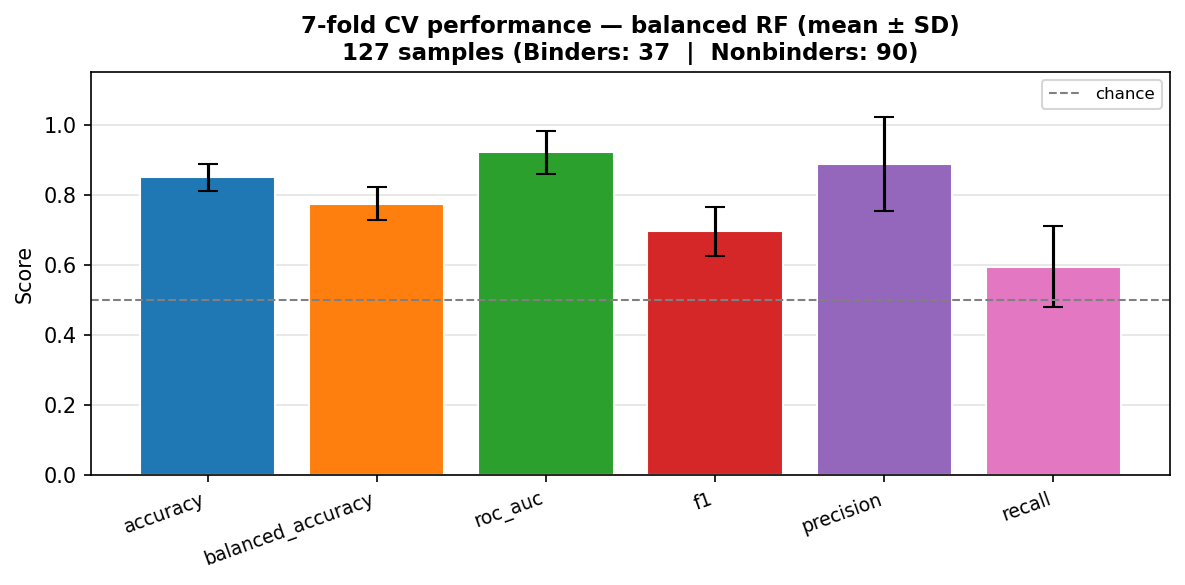

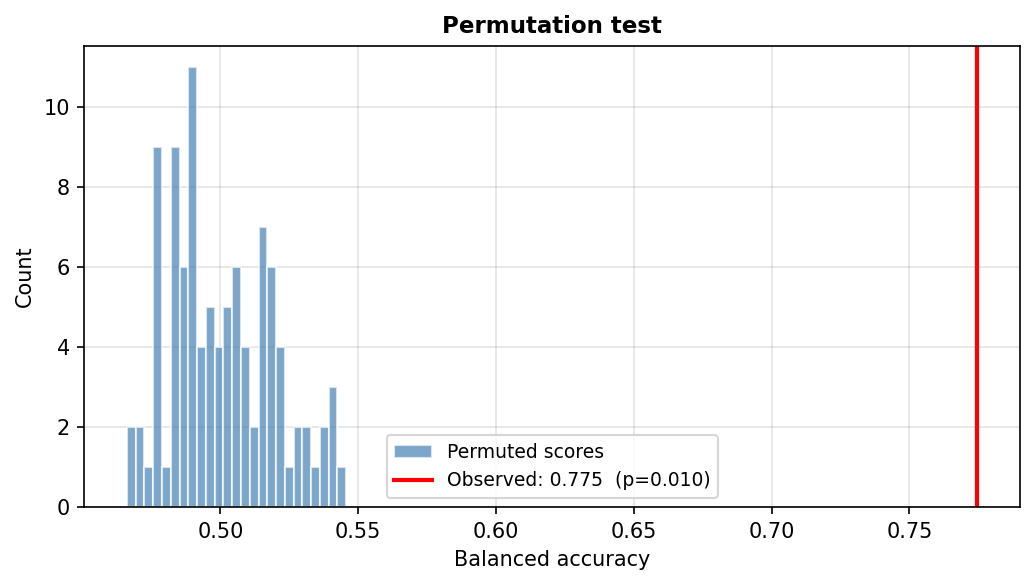

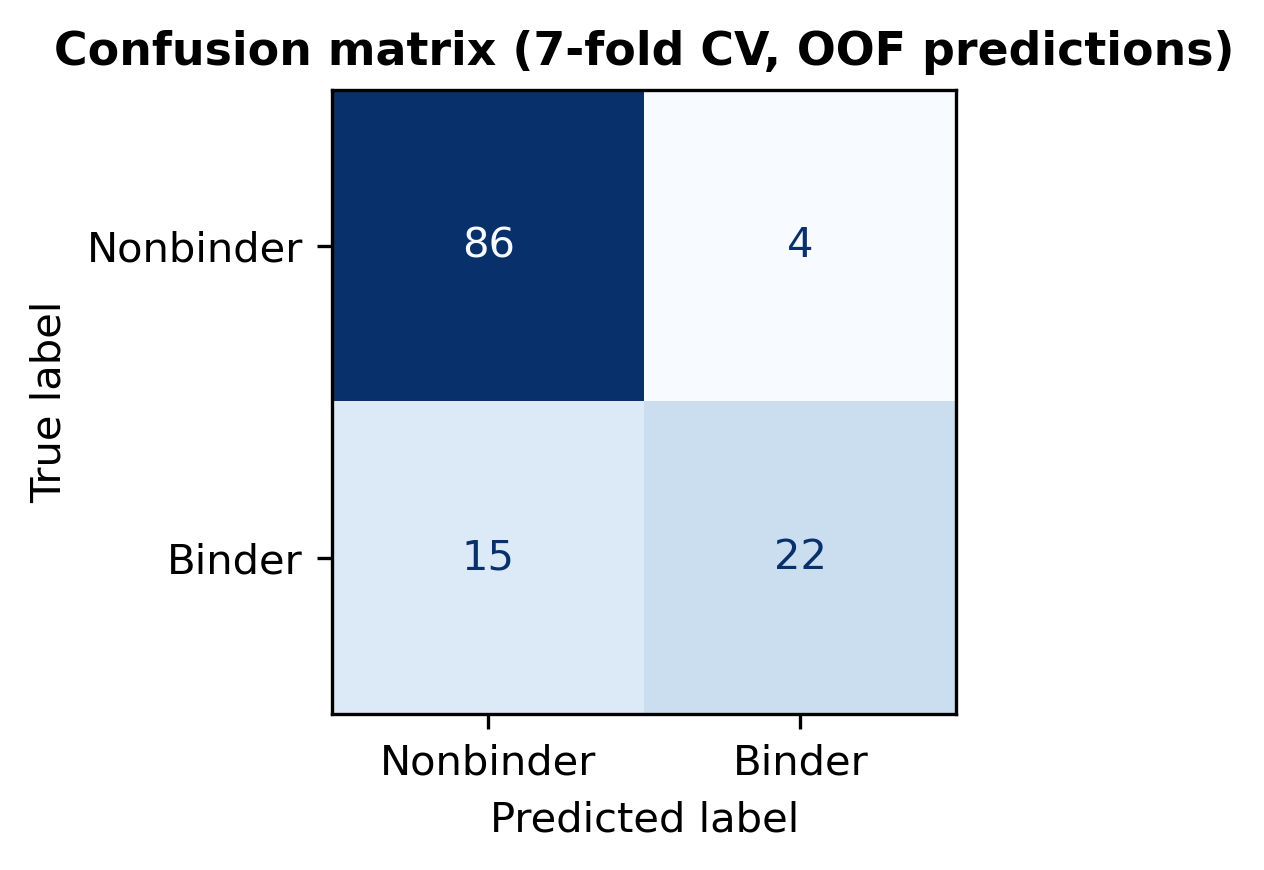

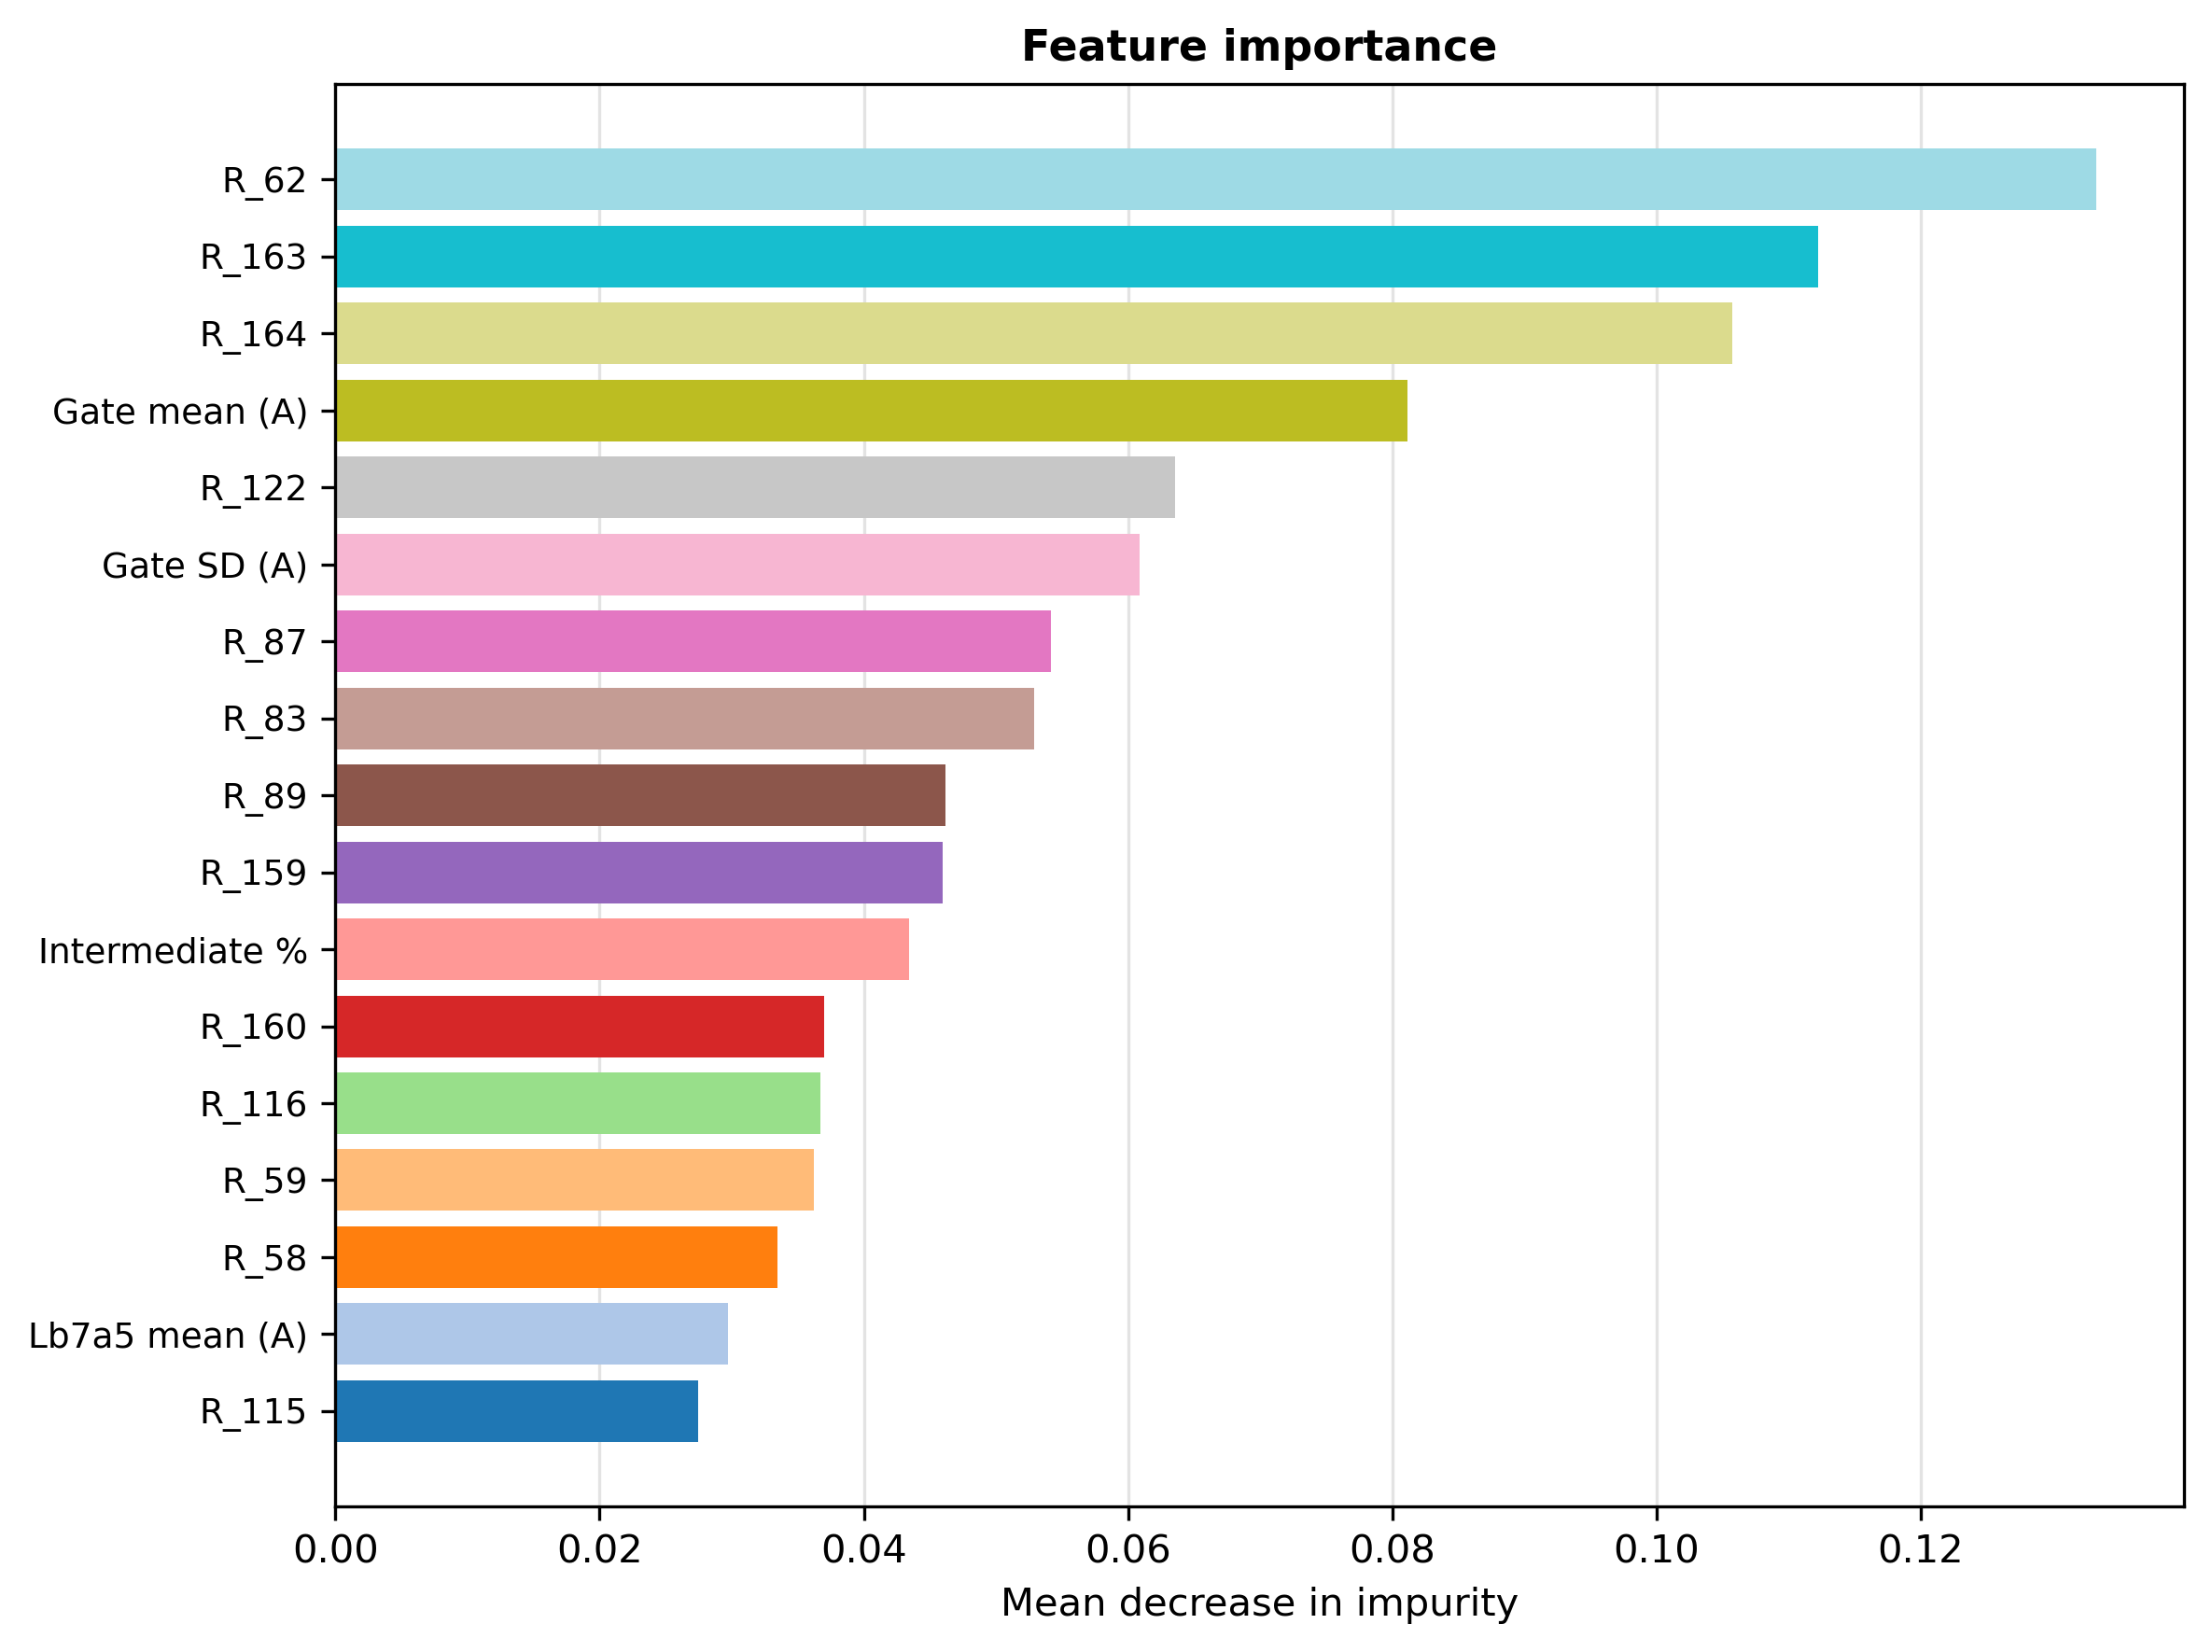

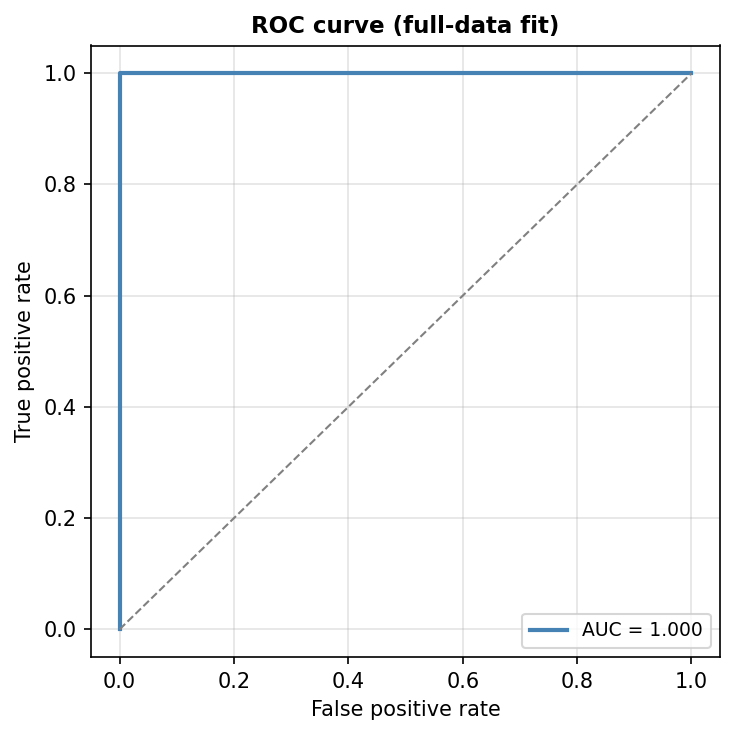


--- Classification report (7-fold CV, OOF predictions) ---
              precision    recall  f1-score   support

   Nonbinder       0.85      0.96      0.90        90
      Binder       0.85      0.59      0.70        37

    accuracy                           0.85       127
   macro avg       0.85      0.78      0.80       127
weighted avg       0.85      0.85      0.84       127



In [34]:
# -------------------------------------------------------------------
# Figure 1: CV metric summary
# -------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(8, 4), dpi=150)
metric_names = list(metrics.keys())
means = [metrics[m].mean() for m in metric_names]
sds   = [metrics[m].std()  for m in metric_names]
x     = np.arange(len(metric_names))

ax1.bar(x, means, yerr=sds, capsize=5,
        color=plt.get_cmap("tab10")(np.linspace(0, 0.6, len(metric_names))),
        edgecolor="white")
ax1.set_xticks(x)
ax1.set_xticklabels(metric_names, rotation=20, ha="right", fontsize=9)
ax1.set_ylabel("Score", fontsize=10)
ax1.set_ylim(0, 1.15)
ax1.axhline(0.5, color="gray", linestyle="--", lw=1, label="chance")
ax1.set_title(f"{N_SPLITS}-fold CV performance — balanced RF (mean ± SD)\n{len(y)} samples (Binders: {n_binders}  |  Nonbinders: {n_nonbinders})",
              fontsize=11, fontweight="bold")
ax1.legend(fontsize=8)
ax1.grid(True, axis="y", alpha=0.35)
ax1.set_axisbelow(True)
plt.tight_layout()

# -------------------------------------------------------------------
# Figure 2: permutation test
# -------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(7, 4), dpi=150)
ax2.hist(perm_scores, bins=25, color="steelblue", alpha=0.7, edgecolor="white",
         label="Permuted scores")
ax2.axvline(score, color="red", lw=2, label=f"Observed: {score:.3f}  (p={pval:.3f})")
ax2.set_xlabel("Balanced accuracy", fontsize=10)
ax2.set_ylabel("Count", fontsize=10)
ax2.set_title("Permutation test", fontsize=11, fontweight="bold")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.35)
ax2.set_axisbelow(True)
plt.tight_layout()

# -------------------------------------------------------------------
# Figure 3: confusion matrix
# -------------------------------------------------------------------
y_pred_cv = cross_val_predict(rf, X, y, cv=cv)   # OOF predictions
fig3, ax3 = plt.subplots(figsize=(7, 3), dpi=300)
cm_mat = confusion_matrix(y, y_pred_cv)
disp   = ConfusionMatrixDisplay(cm_mat, display_labels=["Nonbinder", "Binder"])
disp.plot(ax=ax3, colorbar=False, cmap="Blues")
ax3.set_title(f"Confusion matrix ({N_SPLITS}-fold CV, OOF predictions)", fontsize=11, fontweight="bold")
plt.tight_layout()

# -------------------------------------------------------------------
# Figure 4: feature importances
# -------------------------------------------------------------------
mdi_imp  = rf.feature_importances_
perm_imp = permutation_importance(rf, X, y, n_repeats=30, random_state=42, n_jobs=1)

sorted_idx      = np.argsort(mdi_imp)
feat_names      = [feature_cols[i] for i in sorted_idx]
perm_sorted_idx = np.argsort(perm_imp.importances_mean)
feat_names_perm = [feature_cols[i] for i in perm_sorted_idx]

fig4, axes4 = plt.subplots(figsize=(8, 6), dpi=300)

axes4.barh(range(len(sorted_idx)), mdi_imp[sorted_idx],
              color=plt.get_cmap("tab20")(np.linspace(0, 1, len(sorted_idx))))
axes4.set_yticks(range(len(sorted_idx)))
axes4.set_yticklabels(feat_names, fontsize=9)
axes4.set_xlabel("Mean decrease in impurity", fontsize=10)
axes4.set_title("Feature importance", fontsize=11, fontweight="bold")
axes4.grid(True, axis="x", alpha=0.35)
axes4.set_axisbelow(True)
plt.tight_layout()

# -------------------------------------------------------------------
# Figure 5: ROC curve
# -------------------------------------------------------------------
fpr, tpr, _ = roc_curve(y, y_prob)
roc_auc      = auc(fpr, tpr)

fig5, ax5 = plt.subplots(figsize=(5, 5), dpi=150)
ax5.plot(fpr, tpr, lw=2, color="steelblue", label=f"AUC = {roc_auc:.3f}")
ax5.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
ax5.set_xlabel("False positive rate", fontsize=10)
ax5.set_ylabel("True positive rate", fontsize=10)
ax5.set_title("ROC curve (full-data fit)", fontsize=11, fontweight="bold")
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.35)
ax5.set_axisbelow(True)
plt.tight_layout()

plt.show()

print(f"\n--- Classification report ({N_SPLITS}-fold CV, OOF predictions) ---")
print(classification_report(y, y_pred_cv, target_names=["Nonbinder", "Binder"],
                             zero_division=0))

path   = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/analysis"

# -------------------------------------------------------------------
# Optional: save outputs
# -------------------------------------------------------------------
fig1.savefig(os.path.join(path, "ML", f"RF_performance_metrics_{len(y)}samples.png"),   dpi=300, bbox_inches="tight")
fig3.savefig(os.path.join(path, "ML", f"RF_confusion_matrix_{len(y)}samples.png"),  dpi=300, bbox_inches="tight")
fig4.savefig(os.path.join(path, "ML", f"RF_feat_importance_{len(y)}samples.png"),  dpi=300, bbox_inches="tight")

# fig1.savefig(os.path.join(path, "ML", f"all_feats_RF_performance_metrics_{len(y)}samples.png"),   dpi=300, bbox_inches="tight")
# fig3.savefig(os.path.join(path, "ML", f"all_feats_RF_confusion_matrix_{len(y)}samples.png"),  dpi=300, bbox_inches="tight")
# fig4.savefig(os.path.join(path, "ML", f"all_feats_RF_feat_importance_{len(y)}samples.png"),  dpi=300, bbox_inches="tight")

## Multiclass Classification
Testing the Random Forest as a 4-class model: **Binder**, **False Positive**, **Low Confidence**, **Fail Geometry**.

In [35]:
# -------------------------------------------------------------------
# Multiclass labels
# Adjust column name below if your sheet uses a different header
# -------------------------------------------------------------------
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    balanced_accuracy_score, f1_score, classification_report, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.model_selection import cross_val_predict

GROUP_COL = "Group"  # <-- change if needed

le = LabelEncoder()
y_mc = le.fit_transform(df[GROUP_COL].values)
class_names = le.classes_

print("Classes:", list(class_names))
print("Class distribution:")
for cls, encoded in zip(class_names, range(len(class_names))):
    print(f"  {cls}: {(y_mc == encoded).sum()}")
print(f"  Total: {len(y_mc)}")


Classes: ['binder', 'fail_gate', 'low_pkt', 'nonbinder']
Class distribution:
  binder: 37
  fail_gate: 10
  low_pkt: 9
  nonbinder: 71
  Total: 127


In [36]:
# -------------------------------------------------------------------
# Multiclass RF + stratified CV
# -------------------------------------------------------------------
from sklearn.metrics import make_scorer

rf_mc = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
)

scoring_mc = {
    "accuracy":          "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc":           "roc_auc_ovr",          # one-vs-rest, uses predict_proba
    "f1":                make_scorer(f1_score,        average="macro", zero_division=0),
    "precision":         make_scorer(precision_score, average="macro", zero_division=0),
    "recall":            make_scorer(recall_score,    average="macro", zero_division=0),
}

cv_mc = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

cv_mc_results = cross_validate(
    rf_mc, X, y_mc, cv=cv_mc,
    scoring=scoring_mc,
    return_train_score=False,
)

metrics_mc = {k.replace("test_", ""): v for k, v in cv_mc_results.items()
              if k.startswith("test_")}

print(f"--- {N_SPLITS}-fold stratified CV (multiclass, balanced RF) ---")
mc_df = pd.DataFrame({
    k: {"Mean": round(v.mean(), 3), "SD": round(v.std(), 3)}
    for k, v in metrics_mc.items()
}).T
print(mc_df.to_string())


--- 7-fold stratified CV (multiclass, balanced RF) ---
                    Mean     SD
accuracy           0.716  0.021
balanced_accuracy  0.394  0.023
roc_auc            0.812  0.086
f1                 0.380  0.020
precision          0.397  0.022
recall             0.394  0.023


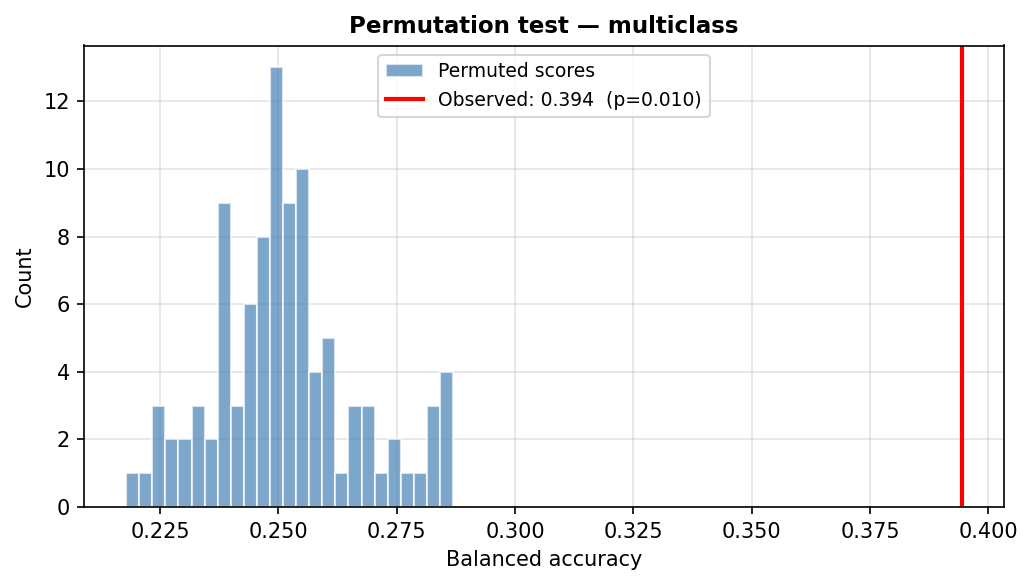

Multiclass permutation test  |  Observed balanced accuracy: 0.394  |  p-value: 0.010


In [37]:
# -------------------------------------------------------------------
# Permutation test (multiclass, balanced accuracy)
# -------------------------------------------------------------------
score_mc, perm_scores_mc, pval_mc = permutation_test_score(
    rf_mc, X, y_mc, cv=cv_mc, scoring="balanced_accuracy",
    n_permutations=100, random_state=42, n_jobs=1,
)

fig_pm, ax_pm = plt.subplots(figsize=(7, 4), dpi=150)
ax_pm.hist(perm_scores_mc, bins=25, color="steelblue", alpha=0.7, edgecolor="white",
           label="Permuted scores")
ax_pm.axvline(score_mc, color="red", lw=2,
              label=f"Observed: {score_mc:.3f}  (p={pval_mc:.3f})")
ax_pm.set_xlabel("Balanced accuracy", fontsize=10)
ax_pm.set_ylabel("Count", fontsize=10)
ax_pm.set_title("Permutation test — multiclass", fontsize=11, fontweight="bold")
ax_pm.legend(fontsize=9)
ax_pm.grid(True, alpha=0.35)
ax_pm.set_axisbelow(True)
plt.tight_layout()
plt.show()

print(f"Multiclass permutation test  |  Observed balanced accuracy: {score_mc:.3f}  |  p-value: {pval_mc:.3f}")


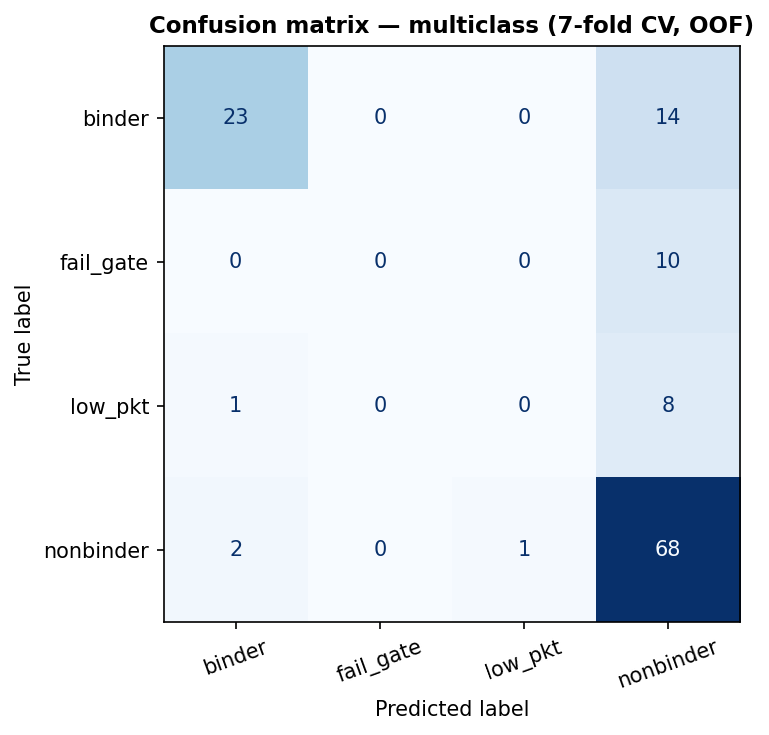

--- Classification report (multiclass, OOF) ---
              precision    recall  f1-score   support

      binder       0.88      0.62      0.73        37
   fail_gate       0.00      0.00      0.00        10
     low_pkt       0.00      0.00      0.00         9
   nonbinder       0.68      0.96      0.80        71

    accuracy                           0.72       127
   macro avg       0.39      0.39      0.38       127
weighted avg       0.64      0.72      0.66       127



In [38]:
# -------------------------------------------------------------------
# Confusion matrix (4-class, OOF predictions)
# -------------------------------------------------------------------
y_pred_mc_cv = cross_val_predict(rf_mc, X, y_mc, cv=cv_mc)

fig_cm, ax_cm = plt.subplots(figsize=(6, 5), dpi=150)
cm_mc = confusion_matrix(y_mc, y_pred_mc_cv)
disp_mc = ConfusionMatrixDisplay(cm_mc, display_labels=class_names)
disp_mc.plot(ax=ax_cm, colorbar=False, cmap="Blues",
             xticks_rotation=20)
ax_cm.set_title(f"Confusion matrix — multiclass ({N_SPLITS}-fold CV, OOF)",
                fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

path   = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/analysis"
# -------------------------------------------------------------------
# Optional: save outputs
# -------------------------------------------------------------------
fig_cm.savefig(os.path.join(path, "ML/multiclass", f"multiclass_RF_confusion_matrix_{len(y)}samples.png"),   dpi=300, bbox_inches="tight")

print("--- Classification report (multiclass, OOF) ---")
print(classification_report(y_mc, y_pred_mc_cv, target_names=class_names, zero_division=0))


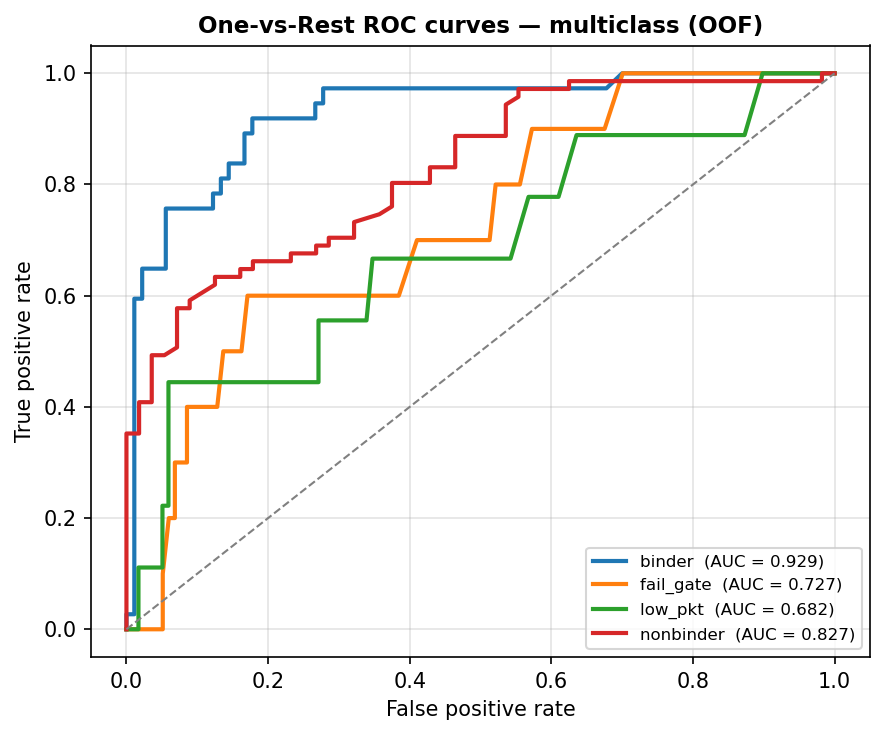

In [39]:
# -------------------------------------------------------------------
# One-vs-Rest ROC curves per class
# -------------------------------------------------------------------
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# OOF probability estimates for each class
y_prob_mc_cv = cross_val_predict(rf_mc, X, y_mc, cv=cv_mc, method="predict_proba")

# Binarize true labels for OvR evaluation
y_mc_bin = label_binarize(y_mc, classes=np.arange(len(class_names)))

# Group colors matching project palette
palette = {
    'Binder':         '#648FFF',   # blue
    'False Positive': '#DC267F',   # magenta
    'Low Confidence': '#FE6100',   # orange
    'Fail Geometry':  '#FFB000',   # gold
}

fig_roc, ax_roc = plt.subplots(figsize=(6, 5), dpi=150)

for i, cls in enumerate(class_names):
    fpr_i, tpr_i, _ = roc_curve(y_mc_bin[:, i], y_prob_mc_cv[:, i])
    roc_auc_i = auc(fpr_i, tpr_i)
    color = palette.get(cls, None)
    ax_roc.plot(fpr_i, tpr_i, lw=2, color=color,
                label=f"{cls}  (AUC = {roc_auc_i:.3f})")

ax_roc.plot([0, 1], [0, 1], color="gray", linestyle="--", lw=1)
ax_roc.set_xlabel("False positive rate", fontsize=10)
ax_roc.set_ylabel("True positive rate", fontsize=10)
ax_roc.set_title("One-vs-Rest ROC curves — multiclass (OOF)",
                 fontsize=11, fontweight="bold")
ax_roc.legend(fontsize=8, loc="lower right")
ax_roc.grid(True, alpha=0.35)
ax_roc.set_axisbelow(True)
plt.tight_layout()
plt.show()

path   = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/analysis"
# -------------------------------------------------------------------
# Optional: save outputs
# -------------------------------------------------------------------
fig_roc.savefig(os.path.join(path, "ML/multiclass", f"multiclass_RF_ROC-AUC_{len(y)}samples.png"),   dpi=300, bbox_inches="tight")


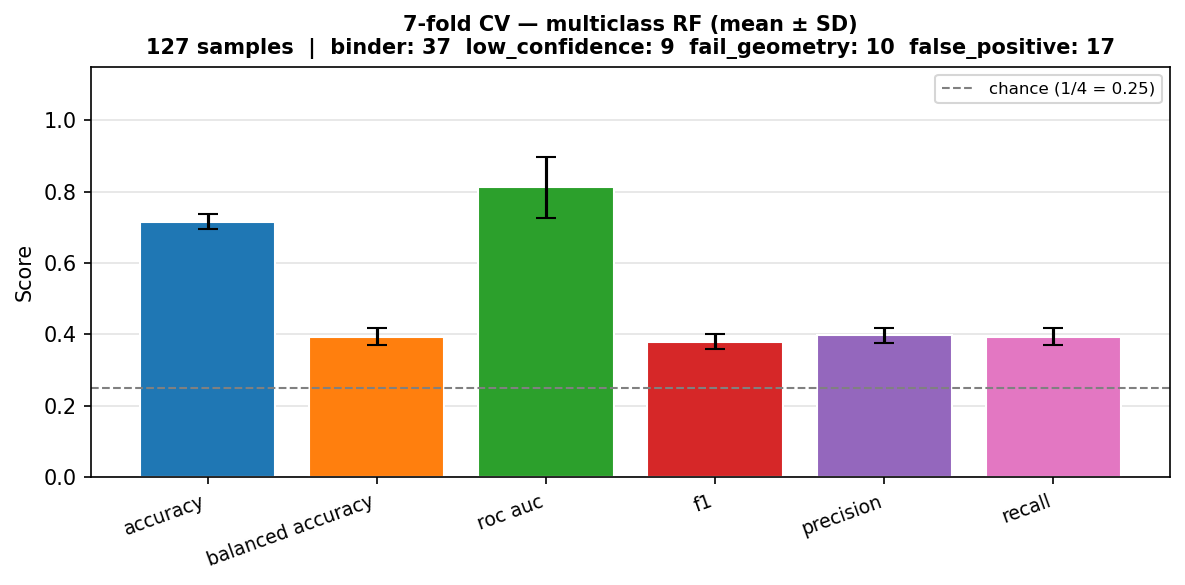

In [40]:
# -------------------------------------------------------------------
# CV metric bar chart — multiclass (matches binary metric set)
# -------------------------------------------------------------------
fig_mc_bar, ax_mc_bar = plt.subplots(figsize=(8, 4), dpi=150)

# Use same display order as binary model
metric_order = ["accuracy", "balanced_accuracy", "roc_auc", "f1", "precision", "recall"]
mc_metric_names = [m for m in metric_order if m in metrics_mc]

mc_means = [metrics_mc[m].mean() for m in mc_metric_names]
mc_sds   = [metrics_mc[m].std()  for m in mc_metric_names]
x_mc     = np.arange(len(mc_metric_names))

ax_mc_bar.bar(x_mc, mc_means, yerr=mc_sds, capsize=5,
              color=plt.get_cmap("tab10")(np.linspace(0, 0.6, len(mc_metric_names))),
              edgecolor="white")
ax_mc_bar.set_xticks(x_mc)
ax_mc_bar.set_xticklabels(
    [m.replace("_", " ") for m in mc_metric_names], rotation=20, ha="right", fontsize=9)
ax_mc_bar.set_ylabel("Score", fontsize=10)
ax_mc_bar.set_ylim(0, 1.15)
n_classes = len(class_names)
ax_mc_bar.axhline(1/n_classes, color="gray", linestyle="--", lw=1,
                  label=f"chance (1/{n_classes} = {1/n_classes:.2f})")
ax_mc_bar.set_title(
    f"{N_SPLITS}-fold CV — multiclass RF (mean ± SD)\n"
    f"{len(y_mc)} samples  |  binder: 37  low_confidence: 9  fail_geometry: 10  false_positive: 17",
    fontsize=10, fontweight="bold")
ax_mc_bar.legend(fontsize=8)
ax_mc_bar.grid(True, axis="y", alpha=0.35)
ax_mc_bar.set_axisbelow(True)
plt.tight_layout()
plt.show()

path   = "/Users/ivanatang/Library/CloudStorage/OneDrive-UCB-O365/Shirts Lab/LCA_boltz_models/analysis"
# -------------------------------------------------------------------
# Optional: save outputs
# -------------------------------------------------------------------
fig_mc_bar.savefig(os.path.join(path, "ML/multiclass", f"multiclass_RF_performance_metrics_{len(y)}samples.png"),   dpi=300, bbox_inches="tight")